In [1]:
from polyergalio.types import Serializable
%load_ext autoreload
%autoreload 2

import json
import os
import numpy as np
import time

import matplotlib.pyplot as plt
from polyergalio.encoders.text_encoders import TextProcessor, DistortionTask
from polyergalio.encoders.tokenizer import SentencePieceTokenizer, TokenSequenceBuilder, fit_tokenizer, \
    SPECIAL_TOKEN_PIECES, TokenSequenceBuilder, Tokenizer
from polyergalio.encoders.pipeline import UniversalPipeline
from polyergalio.generators.data_generators import token_accuracy
from polyergalio.models.constants import DECISION_TYPES, ClassificationTask
from polyergalio.models.embedding.embedding import TextEmbedding
from polyergalio.models.embedding.positional import RopeEmbedding
from polyergalio.models.layers.basal_layers import DropoutLayer, FullyConnectedLayer, RMSNormLayer
from polyergalio.models.layers.mixture_layers import MixtureOfExperts
from polyergalio.models.layers.decision_layers import (
    DecisionHead,
    decision_correct,
    decode_decisions,
    masked_softmax,
)
from polyergalio.models.layers.operator_layers import LatentSum, MaskGather
from polyergalio.models.layers.spectre_layers import SpectreAttention
from polyergalio.models.model_loss import CrossEntropyLoss, DecisionLoss
from polyergalio.models.neural_network import NeuralNetwork
from polyergalio.models.optimizers import Adam




In [2]:
# THIS IS SUPER KLUDGEY -- clean it up...

In [3]:
# TOKENIZER
TARGET_VOCAB_SIZE = 35000
SEQUENCE_LENGTH = 512

corpus_path = f"../data/decision_data"
all_json = []

for fn in os.listdir(corpus_path):
    if fn.endswith(".jsonl"):
        with open(f"{corpus_path}/{fn}", "r") as handle:
            for line in handle:
                try:
                    all_json.append(json.loads(line))
                except:
                    continue
    elif fn.endswith(".json"):
        with open(f"{corpus_path}/{fn}", "r") as handle:
            try:
                one_dict = json.loads(line)
                if "options" in one_dict.keys():
                    all_json.append(one_dict)
            except:
                continue



In [4]:
all_json

[{'id': 0,
  'decisiontype': 'choice',
  'instructions': 'この患者にはどのトリアージレベルを割り当てますか？',
  'options': ['1 蘇生', '2 緊急', '3 準緊急', '4 低緊急', '5 非緊急'],
  'state': {'patient_id': 'JA-00001',
   'age': 62,
   'complaint': '手首の骨折の疑い',
   'arrival': '自力来院',
   'heart_rate': 89,
   'systolic_bp': 94,
   'spo2': 94,
   'temperature_c': 38.7,
   'pain_score': 9},
  'answer': 2,
  'option': '3 準緊急',
  'record': {'patient_id': 'JA-00001',
   'age': 62,
   'complaint': '手首の骨折の疑い',
   'arrival': '自力来院',
   'heart_rate': 89,
   'systolic_bp': 94,
   'spo2': 94,
   'temperature_c': 38.7,
   'pain_score': 9}},
 {'id': 1,
  'decisiontype': 'choice',
  'instructions': 'この患者にはどのトリアージレベルを割り当てますか？',
  'options': ['1 蘇生', '2 緊急', '3 準緊急', '4 低緊急', '5 非緊急'],
  'state': {'patient_id': 'JA-00002',
   'age': 23,
   'complaint': '腹痛',
   'arrival': '転院搬送',
   'heart_rate': 79,
   'systolic_bp': 102,
   'spo2': 96,
   'temperature_c': 37.0,
   'pain_score': 0},
  'answer': 2,
  'option': '3 準緊急',
  'record': {'patient_

In [5]:
print(len(all_json))

382304


In [10]:
# flatten out all of our strings for tokenizer fitting --
line_by_line = []
for sample in all_json:
    concat = ""
    try:
        for key, value in sample.items():
            concat += f"{key}: {value}\n"
            line_by_line.append(concat)
        # if "options" in concat:
        #     line_by_line.append(concat)
        # else:
        #     print('skipped')
    except AttributeError:
        print(sample)


In [11]:
print(line_by_line[5])
print(line_by_line[-10])

id: 0
decisiontype: choice
instructions: この患者にはどのトリアージレベルを割り当てますか？
options: ['1 蘇生', '2 緊急', '3 準緊急', '4 低緊急', '5 非緊急']
state: {'patient_id': 'JA-00001', 'age': 62, 'complaint': '手首の骨折の疑い', 'arrival': '自力来院', 'heart_rate': 89, 'systolic_bp': 94, 'spo2': 94, 'temperature_c': 38.7, 'pain_score': 9}
answer: 2

id: 499
decisiontype: score
instructions: Valora esta reseña de restaurante: 0 = muy mala, 2 = normal, 4 = excelente.
options: ['0', '1', '2', '3', '4']
state: {'review_id': 'ES-00500', 'restaurant': 'Mesón Los Olivos', 'price_level': '€', 'review': 'Volveremos seguro, el chuletón es imprescindible. Hasta el postre fue perfecto.'}
answer: 4
option: 4



In [12]:
# text_processor.fit(line_by_line)

# feature_encoder.connect(text_processor, name="tokenizer")
# feature_encoder.serialize("spectre_decision_feature.pipeline")
# print("feature serialized")

In [13]:
# ---------------------------------
# LOADING TEXT PIPELINE --
feature_encoder = UniversalPipeline(name="feature_encoder")
feature_encoder = feature_encoder.deserialize("spectre_decision_feature.pipeline")

print(feature_encoder["tokenizer"])
feature_encoder["tokenizer"].max_length = SEQUENCE_LENGTH
feature_encoder["tokenizer"].tokenizer.max_length = SEQUENCE_LENGTH
feature_encoder["tokenizer"].tokenizer.sp.max_sentence_length=SEQUENCE_LENGTH

# double-checking ---
feature_encoder["tokenizer"].encode("this")

TextProcessor for text


{'text': array([[  3,  37,   4, ...,   0,   0,   0],
        [  3, 140,   4, ...,   0,   0,   0],
        [  3, 248,   4, ...,   0,   0,   0],
        [  3,  54,   4, ...,   0,   0,   0]], shape=(4, 512)),
 'text_attention_mask': array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], shape=(4, 512))}

edges:
  input      -> embedding
  embedding  -> positional_emb
  positional_emb -> prenorm_0
  prenorm_0  -> attention_0
  attention_0 -> ffna_0
  ffna_0     -> ffnb_0
  ffnb_0     -> postnorm_0
  postnorm_0 -> dropout_0
  dropout_0  -> residual_0
  positional_emb -> residual_0
  residual_0 -> prenorm_1
  prenorm_1  -> attention_1
  attention_1 -> ffnmoe_1
  ffnmoe_1   -> ffnb_1
  ffnb_1     -> postnorm_1
  postnorm_1 -> dropout_1
  dropout_1  -> residual_1
  positional_emb -> residual_1
  residual_1 -> prenorm_2
  prenorm_2  -> attention_2
  attention_2 -> ffnmoe_2
  ffnmoe_2   -> ffnb_2
  ffnb_2     -> postnorm_2
  postnorm_2 -> dropout_2
  dropout_2  -> residual_2
  positional_emb -> residual_2
  residual_2 -> prenorm_3
  prenorm_3  -> attention_3
  attention_3 -> ffnmoe_3
  ffnmoe_3   -> ffnb_3
  ffnb_3     -> postnorm_3
  postnorm_3 -> dropout_3
  dropout_3  -> residual_3
  positional_emb -> residual_3
  residual_3 -> prenorm_4
  prenorm_4  -> attention_4
  attention_4 -> ffnmoe_

<Axes: title={'center': 'spectre_transformer'}>

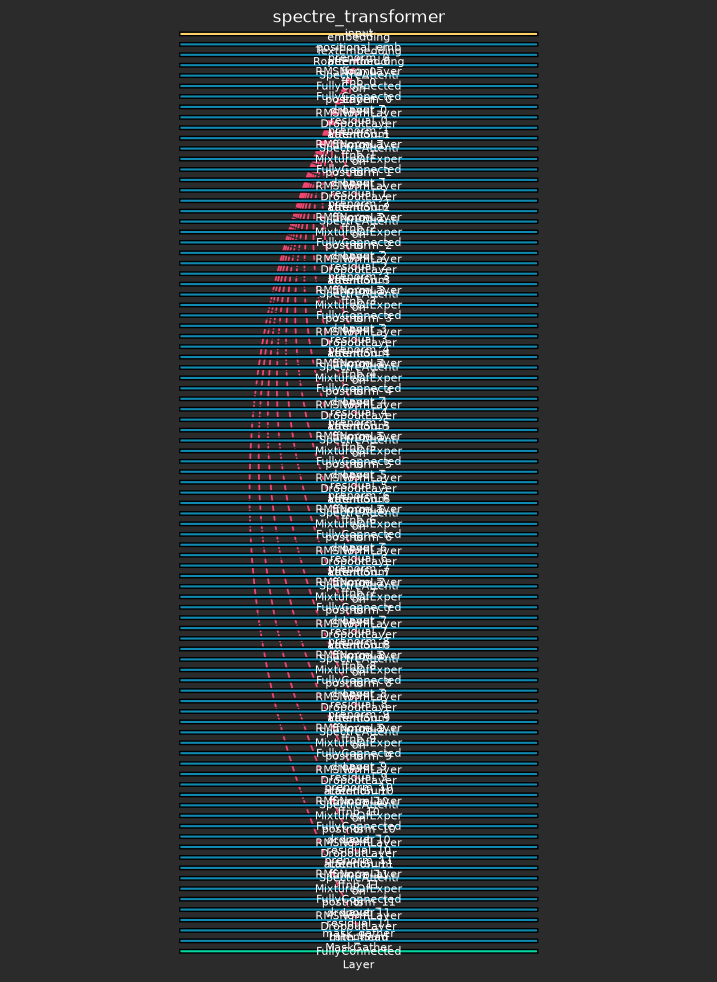

In [16]:
from polyergalio.visuals.nnet_visuals import plot_network

print("edges:")
for producer, consumer in net.edges():
    print(f"  {producer:10s} -> {consumer}")
_temp = feature_encoder["tokenizer"].encode("this is a go")
print(net.summary(_temp["text"]))
print(net.timing_summary(top=10))
plot_network(net)

In [14]:
# feature_encoder pipeline needs to have visibility into these subprocesses:
data = feature_encoder["tokenizer"].distort_batch(line_by_line[-5:])
data.keys()

dict_keys(['input_ids', 'attention_mask', 'segment_ids', 'target_mask', 'labels', 'original_ids', 'task'])

In [15]:
held_out = []
training = []
samples = np.random.choice([True, False], replace=True, size=len(line_by_line), p=[0.05, 0.95])
for idx, hold in enumerate(samples):
    if hold == True:
        held_out.append(line_by_line[idx])
    else:
        training.append(line_by_line[idx])

print(len(held_out))
print(len(training))

134288
2544842


In [16]:
# HIDDEN_DIM = 720
# net.output = net.connect(DecisionHead(hidden_dim=HIDDEN_DIM,
#                                       head_hidden=HIDDEN_DIM,
#                                       routed_scaling=1.5,
#                                       num_groups=16,
#                                       top_groups=8),
#                          net.node("residual_11"),
#                          name="decision_moe_out")
#
# net.disconnect(net.node("decision_moe"))
# net.delete(net.node("decision_moe"))
#
# net.purge()
# plot_network(net)

In [33]:
# how to disconnect / reconnect ----------
# pooler = net.connect(PoolingLayer(),
#                      net.node("residual_11"),
#                      name="pooling")
# HIDDEN_DIM=720
#
# net.output = net.connect(DecisionHead(hidden_dim=HIDDEN_DIM,
#                                       head_hidden=HIDDEN_DIM),
#                          net.node("residual_11"),
#                          name="decision_moe")
#
# net.disconnect(net.node("mask_gather"))
# net.delete(net.node("mask_gather"))
# net.disconnect(net.node("mlm_head"))
# net.delete(net.node("mlm_head"))
#
# net.purge()
# plot_network(net)


task_processor = TokenSequenceBuilder(tokenizer)

task_processor.build_decision_batch(samples, max_length=None)

## yields :
token_ids (batch, sequence_length)
mask (batch, sequence_length) — the encoder's attention mask, token_ids != PAD
marker_pos -> marker token positions (the start of a span)
marker_end -> marker_end token positions (the ending of a span)
token_mask (batch, options) — DecisionHead's own kwargs
decisiontypes (batch,) - one Enum per task
answers (batch,), included only when every sample carries an answer

In [18]:
# DESERIALIZE
net = NeuralNetwork()
net = net.deserialize("spectre_nnet_decider.ergalio")
net.purge()

{'input': ((None,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((512, 720),), 'output': ((512, 720),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((None,),), 'output': ((None,),)}
{'input': ((None,), (None,)), 'output': ((None,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((512, 720),), 'output': ((512, 720),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((None,),), 'output': ((None,),)}
{'input': ((None,), (None,)), 'output': ((None,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((512, 720),), 'output': ((512, 720),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((720,),), 'output': ((720,),)}
{'input': ((None,),), 'output': ((None,),)}
{'input': ((None,), (None

In [19]:

sample = [
    {"id": 0,
     "decisiontype": "choice",
     "instructions": "What should be done with this inventory item?",
     "options": ["reorder", "discount", "hold", "discontinue"],

     "state": {"sku": "SKU-4122", "item": "HDMI cable", "stock": 324, "weekly_sales": 1, "days_to_expiry": None},
     "answer": 3,
     "option": "discontinue",
     "record": {"sku": "SKU-4122", "item": "HDMI cable", "stock": 324, "weekly_sales": 1, "days_to_expiry": None}
     },
          {"id": 0,
     "decisiontype": "choice",
     "instructions": "What should be done with this inventory item?",
     "options": ["reorder", "discount", "hold", "discontinue"],

     "state": {"sku": "SKU-4122", "item": "HDMI cable", "stock": 324, "weekly_sales": 1, "days_to_expiry": None},
     "answer": 3,
     "option": "discontinue",
     "record": {"sku": "SKU-4122", "item": "HDMI cable", "stock": 324, "weekly_sales": 1, "days_to_expiry": None}
     }
          ]


task_processor = TokenSequenceBuilder(feature_encoder["tokenizer"].tokenizer)

# task_processor.build_decision_batch
batch = task_processor.build_decision_batch(sample, max_length=512)
# target = (batch["answer"], batch["option"])


print("edges:")
for producer, consumer in net.edges():
    print(f"  {producer:10s} -> {consumer}")

st = time.time()
logits = net.forward(batch["token_ids"],
                     mask=batch["mask"],
                     marker_pos=batch["marker_pos"],
                     marker_end=batch["marker_end"],
                     token_mask=batch["token_mask"],
                     decisiontypes=batch["decisiontypes"])
print(f'naive forward took {(time.time() - st) / len(sample)} per sample row')
print(net.timing_summary(top=10))


edges:
  input      -> embedding
  embedding  -> positional_emb
  positional_emb -> prenorm_0
  prenorm_0  -> attention_0
  attention_0 -> ffna_0
  ffna_0     -> ffnb_0
  ffnb_0     -> postnorm_0
  postnorm_0 -> dropout_0
  dropout_0  -> residual_0
  positional_emb -> residual_0
  residual_0 -> prenorm_1
  prenorm_1  -> attention_1
  attention_1 -> ffna_1
  ffna_1     -> ffnb_1
  ffnb_1     -> postnorm_1
  postnorm_1 -> dropout_1
  dropout_1  -> residual_1
  positional_emb -> residual_1
  residual_1 -> prenorm_2
  prenorm_2  -> attention_2
  attention_2 -> ffna_2
  ffna_2     -> ffnb_2
  ffnb_2     -> postnorm_2
  postnorm_2 -> dropout_2
  dropout_2  -> residual_2
  positional_emb -> residual_2
  residual_2 -> prenorm_3
  prenorm_3  -> attention_3
  attention_3 -> ffna_3
  ffna_3     -> ffnb_3
  ffnb_3     -> postnorm_3
  postnorm_3 -> dropout_3
  dropout_3  -> residual_3
  positional_emb -> residual_3
  residual_3 -> prenorm_4
  prenorm_4  -> attention_4
  attention_4 -> ffna_4
  ffna

RuntimeError: embedding (TextEmbedding).forward failed on input shape(s) (2, 512): token ids must fall in [0, 35000), got range [0, 54359]

In [14]:
batch

{'token_ids': array([[  3, 139, 830, ...,   0,   0,   0],
        [  3, 139, 830, ...,   0,   0,   0]], shape=(2, 512)),
 'mask': array([[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False]], shape=(2, 512)),
 'marker_pos': array([[12, 14, 16, 18],
        [12, 14, 16, 18]]),
 'marker_end': array([[14, 16, 18, 20],
        [14, 16, 18, 20]]),
 'token_mask': array([[ True,  True,  True,  True],
        [ True,  True,  True,  True]]),
 'decisiontypes': array([1, 1]),
 'answers': array([3, 3])}

In [15]:
loss = DecisionLoss(ordinal_weight=0.25)(logits,
                                         batch["answers"],
                                         batch["token_mask"],
                                         batch["decisiontypes"])

print(loss)
print(logits)

NameError: name 'logits' is not defined

In [48]:
print(net)
# 159_260_541

NeuralNetwork(87 nodes, 121065759 parameters)


In [135]:
held_out = []
training = []
samples = np.random.choice([True, False], replace=True, size=len(all_json), p=[0.05, 0.95])

for idx, hold in enumerate(samples):
    if hold == True:
        held_out.append(all_json[idx])
    else:
        training.append(all_json[idx])

print(len(held_out))
print(len(training))

644
12363


In [18]:
net.layers

[TextEmbedding, 35000 tokens x 720, padding_idx 0,
 RoPE embedding matrix of 512 length, at 720 embedding dimension,
 RMSNorm over 720,
 SPECTRE mixer, sequence 512, hidden 720, 5 heads, band radius 32, 32 memory slots,
 (720, 720), using swish,
 (720, 720), using swish,
 RMSNorm over 720,
 Layer of bool dropout currently at 0.1,
 SummingLayer,
 RMSNorm over 720,
 SPECTRE mixer, sequence 512, hidden 720, 5 heads, band radius 32, 20 memory slots,
 (720, 720), using swish,
 (720, 720), using swish,
 RMSNorm over 720,
 Layer of bool dropout currently at 0.1,
 SummingLayer,
 RMSNorm over 720,
 SPECTRE mixer, sequence 512, hidden 720, 5 heads, band radius 20, 20 memory slots,
 (720, 720), using swish,
 (720, 720), using swish,
 RMSNorm over 720,
 Layer of bool dropout currently at 0.1,
 SummingLayer,
 RMSNorm over 720,
 SPECTRE mixer, sequence 512, hidden 720, 5 heads, band radius 20, 20 memory slots,
 (720, 720), using swish,
 (720, 720), using swish,
 RMSNorm over 720,
 Layer of bool drop

training will take 2472.6 steps
decision_types:  [2 2 2 2]
answer_targets:  [3 0 0 2]
predicted:       [3 0 0 3]
esc? :  [False False False False]
Losses for step   49 
	- Decision loss 2.3889 
	- Confidence loss -8.6349 
mean timings of test dataset per batch of 5: -2.304472707038702, 
 per sample -0.4608945414077404
accuracy: [np.float64(0.7065891472868218)]


<Figure size 640x480 with 0 Axes>

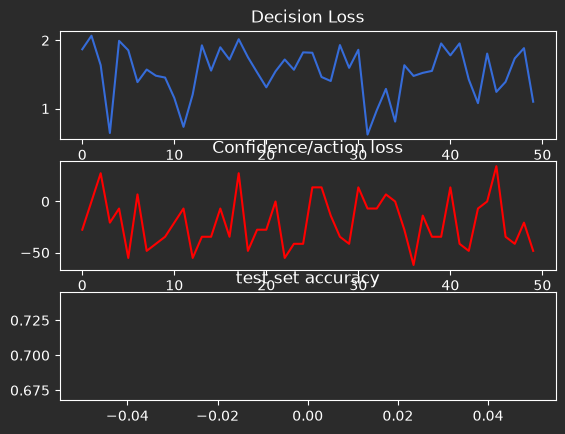

decision_types:  [2 2 2 2]
answer_targets:  [3 0 0 2]
predicted:       [3 0 0 3]
esc? :  [False False False False]
Losses for step   99 
	- Decision loss 2.3764 
	- Confidence loss -8.6349 
mean timings of test dataset per batch of 5: -2.444548477498136, 
 per sample -0.48890969549962715
accuracy: [np.float64(0.7065891472868218), np.float64(0.6879844961240311)]


<Figure size 640x480 with 0 Axes>

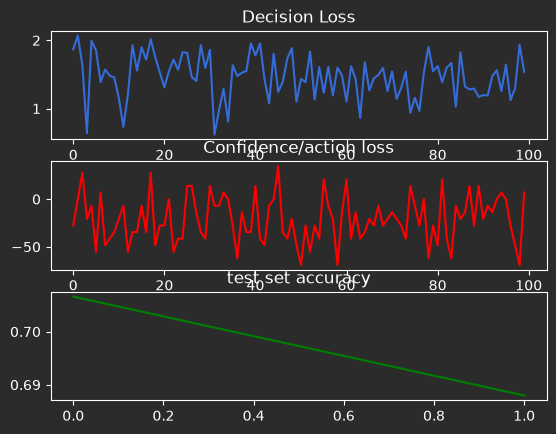

decision_types:  [2 2 2 2]
answer_targets:  [3 0 0 2]
predicted:       [3 0 0 3]
esc? :  [False False False False]
Losses for step  149 
	- Decision loss 2.3478 
	- Confidence loss -8.6349 
mean timings of test dataset per batch of 5: -2.473522799883702, 
 per sample -0.4947045599767404
accuracy: [np.float64(0.7065891472868218), np.float64(0.6879844961240311), np.float64(0.7003875968992248)]


<Figure size 640x480 with 0 Axes>

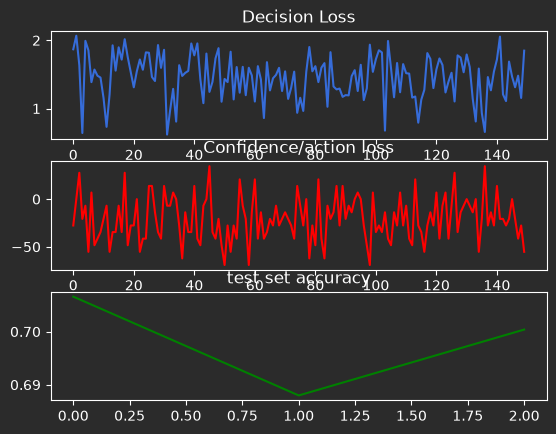

KeyboardInterrupt: 

> /Users/david/Library/CloudStorage/Dropbox/CODE/tools/ml-tools/src/polyergalio/models/layers/basal_layers.py(234)forward()
    232         self.z = self.input @ self.weights + self.bias
    233         self.output = this_activation(self.z)
--> 234         return self.output.reshape(*self.in_shape[:-1], -1)
    235 
    236 



In [151]:
import random
BATCH_SIZE = 5
LR =2e-4
ACT_WEIGHT = 0.01
EPOCHS = 10
LOG_EVERY = 50

all_loss, all_act_loss = [], []
loss_fn = DecisionLoss(ordinal_weight=0.25)
task_processor = TokenSequenceBuilder(feature_encoder["tokenizer"].tokenizer)
optimizer = Adam(LR)

# held_out ----
test_accuracy = []

for epoch in range(0, EPOCHS):
    np.random.shuffle(training)
    optimizer.learning_rate = LR * (0.92 ** epoch)
    net.node("decision_moe_out").component.act_weight = ACT_WEIGHT * (1.2 ** epoch)
    print(f"training will take {len(training) / BATCH_SIZE} steps")

    net.eval()
    net.node("decision_moe_out").component.train()

    for step, start_idx in enumerate(range(0, len(training), BATCH_SIZE)):
        net.zero_gradients()
        _mini_batch = training[start_idx:start_idx+BATCH_SIZE]

        _tok_batch = task_processor.build_decision_batch(
            _mini_batch,
            max_length=SEQUENCE_LENGTH)
        # target = (sample["answer"], sample["option"])

        logits = net.forward(_tok_batch["token_ids"],
                             mask=_tok_batch["mask"],
                             marker_pos=_tok_batch["marker_pos"],
                             marker_end=_tok_batch["marker_end"],
                             token_mask=_tok_batch["token_mask"],
                             decisiontypes=_tok_batch["decisiontypes"])

        act = net.node("decision_moe_out").component.score_act(_tok_batch["answers"])

        loss = loss_fn(logits,
                       _tok_batch["answers"],
                       _tok_batch["token_mask"],
                       _tok_batch["decisiontypes"])


        net.backward(loss_fn.backward())
        optimizer.step(net.layers)

        all_loss.append(loss)
        all_act_loss.append(act)

        this_step = []
        timings = []
        if (step+1) % LOG_EVERY == 0:
            plt.clf()
            for batch in range(0, len(held_out), BATCH_SIZE):
                st = time.time()
                _tok_batch = task_processor.build_decision_batch(
                    held_out[batch:batch+BATCH_SIZE],
                    # random.choices(held_out, k=BATCH_SIZE),
                    max_length=SEQUENCE_LENGTH)

                net.zero_gradients()
                logits = net.forward(_tok_batch["token_ids"],
                                     mask=_tok_batch["mask"],
                                     marker_pos=_tok_batch["marker_pos"],
                                     marker_end=_tok_batch["marker_end"],
                                     token_mask=_tok_batch["token_mask"],
                                     decisiontypes=_tok_batch["decisiontypes"])

                act = net.node("decision_moe_out").component.score_act(_tok_batch["answers"])
                timings.append(st - time.time())
                loss = loss_fn(logits,
                               _tok_batch["answers"],
                               _tok_batch["token_mask"],
                               _tok_batch["decisiontypes"])

                classes = np.argmax(logits, axis=-1)
                acc = np.sum(classes == _tok_batch["answers"]) / len(classes)
                this_step.append(acc)

            print("decision_types: ", _tok_batch["decisiontypes"])
            print("answer_targets: ", _tok_batch["answers"])
            print("predicted:      ", np.argmax(logits, axis=-1))
            print("esc? : ", net.node("decision_moe_out").component.escalate(0.5))
            print(f"Losses for step {step:4d} \n\t- Decision loss {loss:.4f} \n\t- Confidence loss {act:.4f} ")

            avg = np.mean(timings)
            print(f"mean timings of test dataset per batch of {BATCH_SIZE}: {avg}, \n per sample {avg / BATCH_SIZE}")

            test_accuracy.append(np.mean(this_step))
            print("accuracy:", test_accuracy[-5:])

            plt.figure()
            plt.subplot(3,1,1)
            plt.title("Decision Loss")
            plt.plot(all_loss)
            plt.subplot(3,1,2)
            plt.title("Confidence/action loss")
            plt.plot(all_act_loss, color="red")
            plt.subplot(3,1,3)
            plt.title("test set accuracy")
            plt.plot(test_accuracy, color="green")
            plt.show()

    net.serialize("spectre_nnet_decider.ergalio")


In [152]:
net.serialize("spectre_nnet_decider.ergalio")

{'type': 'NeuralNetwork',
 'version': '0.1.4',
 'config': {'name': 'spectre_transformer', 'input_shape': (512,)},
 'weights': {'nodes': [{'name': 'embedding',
    'sources': ['input'],
    'component': {'type': 'TextEmbedding',
     'version': '0.1.4',
     'config': {'num_embeddings': 35000,
      'embedding_dim': 720,
      'padding_idx': 0,
      'special_tokens': None,
      'initialization': 'truncated_normal',
      'initialization_kwargs': {}},
     'weights': {'weights': array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
               0.        ,  0.        ],
             [ 0.01803046, -0.02419441,  0.00903622, ...,  0.00614663,
               0.01864759,  0.01185931],
             [-0.00509322,  0.02190727,  0.00185429, ...,  0.00151834,
               0.0094983 ,  0.01779077],
             ...,
             [-0.00160673, -0.00295732,  0.01611739, ..., -0.01255633,
              -0.00618509,  0.00524729],
             [ 0.02679031,  0.00518633,  0.02107045, ...